# need to make threads to be 8 ..

In [1]:
using Base
ENV["JULIA_NUM_THREADS"] = "auto"
Threads.nthreads()

1

In [ ]:
# Locate flexOPT securely without relying on @__DIR__ (unreliable in IJulia).
# If this notebook is outside the repository, set ENV["FLEXOPT_ROOT"] first.
import Pkg

function find_flexopt_root(start_dir=pwd())
    candidates = String[]
    if haskey(ENV, "FLEXOPT_ROOT")
        push!(candidates, abspath(expanduser(ENV["FLEXOPT_ROOT"])))
    end
    directory = abspath(start_dir)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(candidates)
        project_file = joinpath(candidate, "Project.toml")
        source_dir = joinpath(candidate, "src")
        if isfile(project_file) && isfile(joinpath(source_dir, "commonBatchs.jl"))
            return candidate
        end
    end
    error("Cannot locate flexOPT. Start Jupyter inside the repository or set ENV[\"FLEXOPT_ROOT\"] to its absolute path.")
end

flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
@show VERSION Threads.nthreads() Base.active_project()
\n#Pkg.develop(path="/Users/nobuaki/Documents/Github/sonifSismo.jl")
#Pkg.instantiate()\n

In [ ]:



include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "planet1D.jl"))
planet1D.configure_input!()
include(joinpath(flexopt_root, "src", "GeoPoints.jl"))

using .commonBatchs, .planet1D, .GeoPoints
using Colors



In [4]:
using Statistics

In [5]:
using GLMakie
GLMakie.activate!()
Makie.inline!()

MakieCore.Automatic()

In [6]:
p0 = GeoPoint(35.363602,138.726379) # summit of Mt Fuji


GeoPoint(35.363602, 138.726379, 0.0, [-3.9135527429451863e6, 3.4349489523064685e6, 3.670837394580353e6], 6.3710137775878785e6)

In [7]:


Δx = 300.0 # in metre
Δy = 300.0
Δz = 10.0

altMax = 4.e3 # in metre
altMin = -10.e0 # in metre

horizontalDepth = 20.e3 

20000.0

In [8]:
boxGrids3D=constructLocalBox(p0,Δx,Δy,Δz,-horizontalDepth,horizontalDepth,-horizontalDepth,horizontalDepth,altMin,altMax)

(allGridsInGeoPoints = GeoPoint[GeoPoint(35.18312504112868, 138.50681243687004, -10.55236314804985, [-3.9090153261017334e6, 3.4575761247319216e6, 3.6544843209726927e6], 6.371066561436138e6) GeoPoint(35.18582910669274, 138.50680499787939, -10.539160646301125, [-3.908885405060186e6, 3.4574621124070697e6, 3.6547295182662033e6], 6.371065626746377e6) … GeoPoint(35.54004655592156, 138.50582621082117, 113.60105647710668, [-3.891865748617484e6, 3.4425264978514644e6, 3.6868503637161413e6], 6.37106531893256e6) GeoPoint(35.54275035499471, 138.5058187063534, 115.48308736619421, [-3.8917358275759364e6, 3.4424124855266125e6, 3.687095561009652e6], 6.371066248922919e6); GeoPoint(35.18313110365623, 138.5101060697825, -11.484937302531877, [-3.9092132162547223e6, 3.457350648597494e6, 3.654484333356612e6], 6.371065626741497e6) GeoPoint(35.185835169815086, 138.51009873988366, -11.47173465502355, [-3.909083295213175e6, 3.457236636272642e6, 3.654729530650123e6], 6.371064692051599e6) … GeoPoint(35.54005269706

In [9]:
earthquakePoints = [GeoPoint(35.35,138.71),GeoPoint(35.36,138.72)]
stationPoints    = [GeoPoint(35.351,138.712),GeoPoint(35.361,138.721,alt=-3.e3)]  # array of GeoPoint


2-element Vector{GeoPoint}:
 GeoPoint(35.351, 138.712, 0.0, [-3.913298523275052e6, 3.4364648568486474e6, 3.6696971156907133e6], 6.371018204771608e6)
 GeoPoint(35.361, 138.721, -3000.0, [-3.911517197228428e6, 3.4338125063347584e6, 3.6688657910997155e6], 6.368014706796496e6)

In [10]:

extraPointSets = [
    GeoPointSet("earthquakes", earthquakePoints; color=:red, marker=:star5),
    GeoPointSet("stations", stationPoints; color=:blue, marker=:utriangle),
]

2-element Vector{GeoPointSet}:
 GeoPointSet("earthquakes", GeoPoint[GeoPoint(35.35, 138.71, 0.0, [-3.91322679769614e6, 3.4366438126280764e6, 3.669606624210372e6], 6.371018556049784e6), GeoPoint(35.36, 138.72, 0.0, [-3.913344097320077e6, 3.435537230498888e6, 3.670511489269142e6], 6.371015043070503e6)], :red, :star5)
 GeoPointSet("stations", GeoPoint[GeoPoint(35.351, 138.712, 0.0, [-3.913298523275052e6, 3.4364648568486474e6, 3.6696971156907133e6], 6.371018204771608e6), GeoPoint(35.361, 138.721, -3000.0, [-3.911517197228428e6, 3.4338125063347584e6, 3.6688657910997155e6], 6.368014706796496e6)], :blue, :utriangle)

In [11]:
eqLocal = [
    p_ECEF_to_local(p.ecef, p0.ecef, boxGrids3D.rotationMatrix)
    for p in earthquakePoints
]

staLocal = [
    p_ECEF_to_local(p.ecef, p0.ecef, boxGrids3D.rotationMatrix)
    for p in stationPoints
]

2-element Vector{SVector{3, Float64}}:
 [-1307.073289566552, -1397.9887145638634, 4.139745574413773]
 [-488.65808265725735, -298.0092346245262, -2999.096509087992]

In [12]:
eqLocal = GeoPoints_to_local(earthquakePoints, boxGrids3D)
staLocal = GeoPoints_to_local(stationPoints, boxGrids3D)

2-element Vector{SVector{3, Float64}}:
 [-1307.073289566552, -1397.9887145638634, 4.139745574413773]
 [-488.65808265725735, -298.0092346245262, -2999.096509087992]

In [13]:
seismicModel3D=lazyProduceOrLoad("seismicModel3D_Fuji",getParamsAndTopo,boxGrids3D.allGridsInGeoPoints,boxGrids3D.effectiveRadii,0.5)

Loading from ./tmp/seismicModel3D_Fuji.jld2


(ρ = [2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6; … ; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6;;; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6; … ; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6;;; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6; … ; 2.6 2.6 … 2.6 2.6; 2.6 2.6 … 2.6 2.6;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vpv = [5.800000000000001 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8; … ; 5.8 5.8 … 5.8 5.8; 5.8 5.799999999999999 … 5.8 5.8;;; 5.8 5.8 … 5.8 5.8; 5.8 5.799999999999999 … 5.8 5.8; … ; 5.8 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8;;; 5.8 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8; … ; 5.8 5.8 … 5.8 5.8; 5.8 5.8 … 5.8 5.8;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0

In [14]:
Nx3D,Ny3D,Nz3D=boxGrids3D.Nx, boxGrids3D.Ny, boxGrids3D.Nz

(134, 134, 402)

In [15]:
boxGrids3D.allGridsInGeoPoints[1,1,1]

GeoPoint(35.18312504112868, 138.50681243687004, -10.55236314804985, [-3.9090153261017334e6, 3.4575761247319216e6, 3.6544843209726927e6], 6.371066561436138e6)

In [16]:


x = [p.xyz[1] for p in boxGrids3D.allGridsInCartesian[:,1,1]]*1.e-3
y = [p.xyz[2] for p in boxGrids3D.allGridsInCartesian[1,:,1]]*1.e-3
z = [p.xyz[3] for p in boxGrids3D.allGridsInCartesian[1,1,:]]*1.e-3


ρ = seismicModel3D.ρ

sx = max(1, ceil(Int, size(ρ, 1) / 512))
sy = max(1, ceil(Int, size(ρ, 2) / 512))
sz = max(1, ceil(Int, size(ρ, 3) / 256))

ρ_plot = ρ[1:sx:end, 1:sy:end, 1:sz:end]
xg = x[1:sx:end]
yg = y[1:sy:end]
zg = z[1:sz:end]

println("original size = ", size(ρ))
println("plot size = ", size(ρ_plot))
println("strides = ", (sx, sy, sz))


original size = (134, 134, 402)
plot size = (134, 134, 201)
strides = (1, 1, 2)


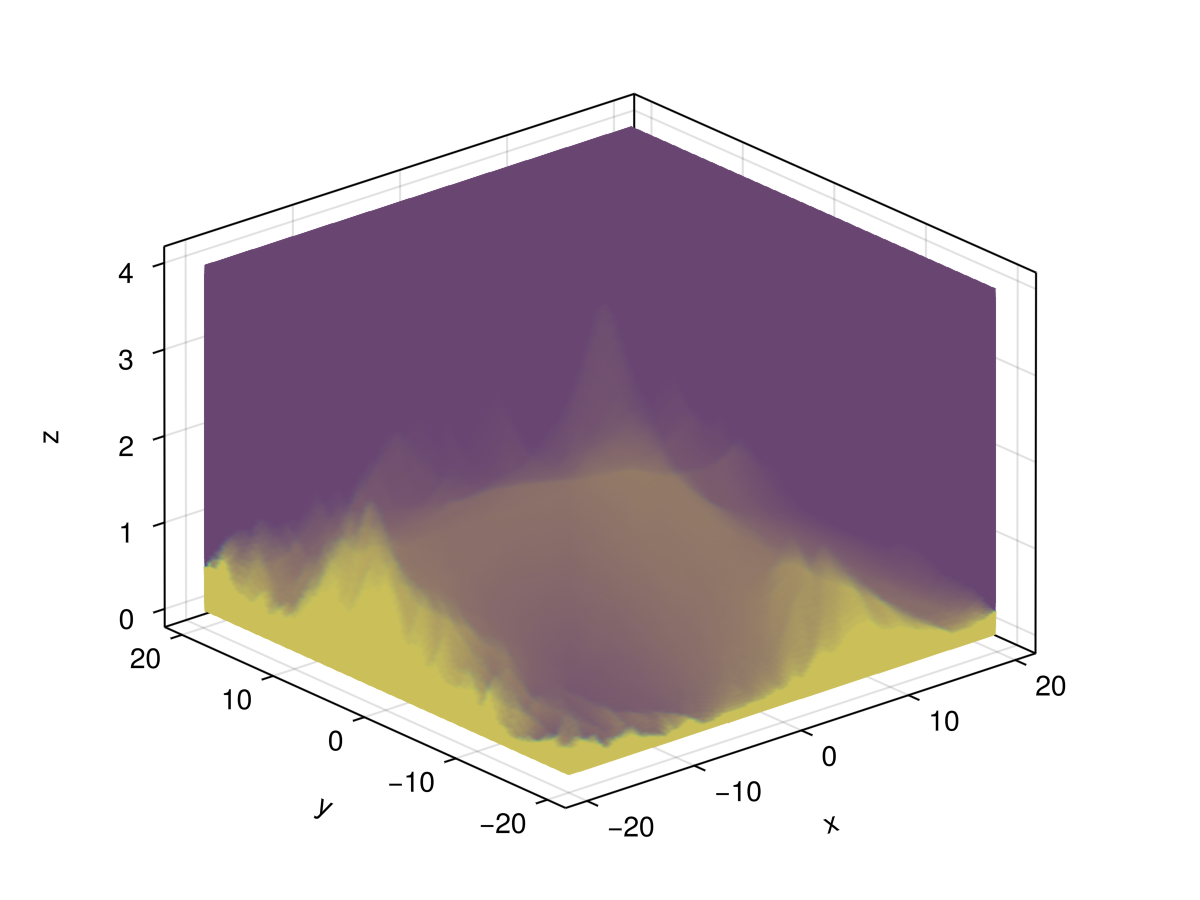

In [17]:




f = Figure()
ax = Axis3(f[1, 1])

volume!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    ρ_plot;
    algorithm = :absorption,
    colormap = :viridis,
)
f

# finding vertical gradient of Vpv

In [18]:
Vp = seismicModel3D.Vpv

# Vertical Vp gradient, same size as Vp
dVp_dz = similar(Vp)

for k in 2:length(z)-1
    dVp_dz[:, :, k] .= (Vp[:, :, k+1] .- Vp[:, :, k-1]) ./ (z[k+1] - z[k-1])
end

dVp_dz[:, :, 1] .= (Vp[:, :, 2] .- Vp[:, :, 1]) ./ (z[2] - z[1])
dVp_dz[:, :, end] .= (Vp[:, :, end] .- Vp[:, :, end-1]) ./ (z[end] - z[end-1])
Gg = dVp_dz[1:sx:end, 1:sy:end, 1:sz:end];

In [19]:
valid = filter(isfinite, vec(abs.(Gg)))
thr = quantile(valid, 0.993)   # strongest 2%
println("threshold = ", thr)
thr=8

threshold = 0.0


8

In [30]:
Pkg.add("MarchingCubes")
using MarchingCubes

   Resolving package versions...
    Updating `~/Documents/Github/flexOPT/Project.toml`
  [299715c1] + MarchingCubes v0.1.11
    Manifest No packages added to or removed from `~/Documents/Github/flexOPT/Manifest.toml`


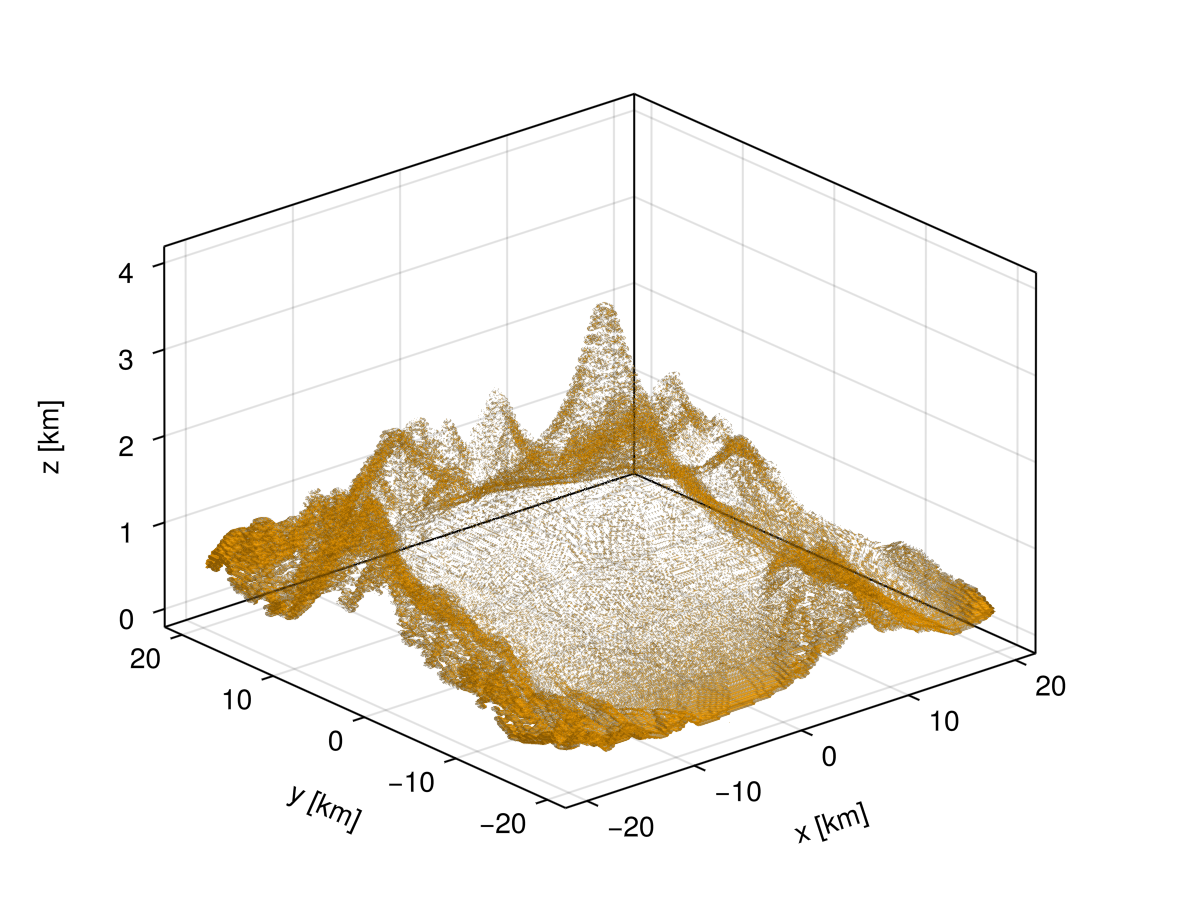

In [34]:
f = Figure()
ax = Axis3(f[1, 1];
    xlabel = "x [km]",
    ylabel = "y [km]",
    zlabel = "z [km]",
)

contour!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    abs.(Gg);
    levels = [thr],
    colormap = [:orange],
    alpha = 0.6,
    transparency = true,
    linewidth = 0,
)
f

In [35]:
using CSV
using DataFrames
using GLMakie

In [46]:
stations_df = CSV.read(
    "/Users/nobuaki/Documents/Github/sonifSismo.jl/exports/stations_available.csv",
    DataFrame,
)

events_df = CSV.read(
    "/Users/nobuaki/Documents/Github/sonifSismo.jl/exports/events_selected.csv",
    DataFrame,
)

println(names(stations_df))
println(names(events_df))

["network", "station", "lat", "lon", "alt_m", "status", "source_note"]
["event_id", "catalog_time_jst", "origin_time_utc", "latitude", "longitude", "depth_km", "altitude_m", "magnitude", "event_type", "event_type_label", "region_name"]


In [54]:
function findcol(df::DataFrame, candidates)
    name_map = Dict(lowercase(String(n)) => n for n in names(df))

    for c in candidates
        key = lowercase(String(c))
        if haskey(name_map, key)
            return name_map[key]
        end
    end

    error("Could not find $(candidates). Available columns: $(names(df))")
end

function nonmissing_rows(df::DataFrame, cols)
    mask = trues(nrow(df))
    for col in cols
        mask .&= .!ismissing.(df[:, col])
    end
    return df[mask, :]
end

nonmissing_rows (generic function with 1 method)

In [81]:
sta_lat_col = findcol(stations_df, [:lat, :latitude])
sta_lon_col = findcol(stations_df, [:lon, :longitude])

sta_alt_col = try
    findcol(stations_df, [:alt, :altitude, :elevation, :elev, :altitude_m])
catch
    nothing
end

stations_valid = nonmissing_rows(stations_df, [sta_lat_col, sta_lon_col])

stationPoints = [
    GeoPoint(
        Float64(row[sta_lat_col]),
        Float64(row[sta_lon_col]);
        alt=
        sta_alt_col === nothing || ismissing(row[sta_alt_col]) ?
            0.0 :
            Float64(row[sta_alt_col]),
    )
    for row in eachrow(stations_valid)
]

5-element Vector{GeoPoint}:
 GeoPoint(35.3666, 138.9102, 0.0, [-3.92440777163061e6, 3.4222489872343694e6, 3.6711086396442098e6], 6.37101272426384e6)
 GeoPoint(35.4487, 138.7525, 0.0, [-3.9110055370662026e6, 3.429557919711533e6, 3.6785327995084976e6], 6.37098386379046e6)
 GeoPoint(35.3135, 138.67583, 0.0, [-3.9129352901366935e6, 3.4405233650999335e6, 3.6663029289391246e6], 6.371031374694627e6)
 GeoPoint(35.425, 138.64517, 0.0, [-3.9057186230282774e6, 3.437885561560418e6, 3.6763904159814403e6], 6.370992198031299e6)
 GeoPoint(35.36582, 138.77818, 0.0, [-3.9165495454451456e6, 3.4313154580386025e6, 3.6710380698369364e6], 6.371012998314581e6)

In [82]:
stationPoints

5-element Vector{GeoPoint}:
 GeoPoint(35.3666, 138.9102, 0.0, [-3.92440777163061e6, 3.4222489872343694e6, 3.6711086396442098e6], 6.37101272426384e6)
 GeoPoint(35.4487, 138.7525, 0.0, [-3.9110055370662026e6, 3.429557919711533e6, 3.6785327995084976e6], 6.37098386379046e6)
 GeoPoint(35.3135, 138.67583, 0.0, [-3.9129352901366935e6, 3.4405233650999335e6, 3.6663029289391246e6], 6.371031374694627e6)
 GeoPoint(35.425, 138.64517, 0.0, [-3.9057186230282774e6, 3.437885561560418e6, 3.6763904159814403e6], 6.370992198031299e6)
 GeoPoint(35.36582, 138.77818, 0.0, [-3.9165495454451456e6, 3.4313154580386025e6, 3.6710380698369364e6], 6.371012998314581e6)

In [83]:
ev_lat_col = findcol(events_df, [:lat, :latitude])
ev_lon_col = findcol(events_df, [:lon, :longitude])

ev_depth_col = try
    findcol(events_df, [:depth, :depth_km, :dep])
catch
    nothing
end

ev_type_col = try
    findcol(events_df, [:type, :event_type, :kind, :class, :label])
catch
    nothing
end

events_valid = nonmissing_rows(events_df, [ev_lat_col, ev_lon_col])

eventPoints = [
    GeoPoint(
        Float64(row[ev_lat_col]),
        Float64(row[ev_lon_col]);
        alt=
        ev_depth_col === nothing || ismissing(row[ev_depth_col]) ?
            0.0 :
            -Float64(row[ev_depth_col]) * 1e3,
    )
    for row in eachrow(events_valid)
]

227-element Vector{GeoPoint}:
 GeoPoint(29.642166666666668, 129.94483333333332, -20500.0, [-3.5506408786433274e6, 4.239772728162442e6, 3.125821667426631e6], 6.352439258435839e6)
 GeoPoint(33.154333333333334, 137.13516666666666, -27610.0, [-3.900829391456359e6, 3.620415214798816e6, 3.4532013432783973e6], 6.344168644197305e6)
 GeoPoint(29.631666666666668, 129.97066666666666, -15890.0, [-3.5554948164419318e6, 4.241681998572464e6, 3.1270925968983946e6], 6.35705259348512e6)
 GeoPoint(23.3935, 122.1005, -11000.0, [-3.1070497213160535e6, 4.952965641661004e6, 2.512407608226698e6], 6.36378964203563e6)
 GeoPoint(38.128, 142.85516666666666, -30380.0, [-3.9853764754117695e6, 3.0190217035876014e6, 3.8978727811812977e6], 6.339647459896532e6)
 GeoPoint(24.895333333333333, 125.44633333333333, -27700.0, [-3.3426464864934166e6, 4.695514376559497e6, 2.656901481761277e6], 6.346673638838614e6)
 GeoPoint(29.7715, 131.1985, -43230.0, [-3.6248924426219286e6, 4.1409000136948023e6, 3.1269471628946178e6], 6.3296

In [84]:
function GeoPoints_to_local(points::AbstractVector{GeoPoint}, boxGrids3D)
    pOrigin = boxGrids3D.pOriginECEF 
    R = boxGrids3D.rotationMatrix

    return [
        p_ECEF_to_local(p.ecef, pOrigin, R)
        for p in points
    ]
end


GeoPoints_to_local (generic function with 1 method)

In [85]:
eqLocal = GeoPoints_to_local(eventPoints, boxGrids3D)
staLocal = GeoPoints_to_local(stationPoints, boxGrids3D)

5-element Vector{SVector{3, Float64}}:
 [16705.485593879894, 347.21488702629927, -22.96461345141468]
 [2371.9250942320045, 9441.574203954548, -37.351522993758145]
 [-4597.136778566789, -5557.234510097959, 13.51492019861201]
 [-7374.539078760332, 6815.310631140689, -29.493062259826125]
 [4707.688107753212, 247.06818832699776, -2.5233742866792626]

In [86]:
eventTypes = ev_type_col === nothing ?
    fill("event", nrow(events_valid)) :
    [
        ismissing(row[ev_type_col]) ? "unknown" : lowercase(String(row[ev_type_col]))
        for row in eachrow(events_valid)
    ]

227-element Vector{String}:
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 ⋮
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"
 "earthquake"

In [87]:
function local_xyz_km(localPoints)
    xs = getindex.(localPoints, 1) .* 1e-3
    ys = getindex.(localPoints, 2) .* 1e-3
    zs = getindex.(localPoints, 3) .* 1e-3
    return xs, ys, zs
end

eqX, eqY, eqZ = local_xyz_km(eqLocal)
staX, staY, staZ = local_xyz_km(staLocal)

([16.705485593879892, 2.3719250942320045, -4.597136778566789, -7.374539078760332, 4.707688107753212], [0.34721488702629927, 9.441574203954548, -5.55723451009796, 6.815310631140689, 0.24706818832699776], [-0.02296461345141468, -0.03735152299375814, 0.01351492019861201, -0.029493062259826126, -0.0025233742866792625])

In [88]:
staX, staY, staZ

([16.705485593879892, 2.3719250942320045, -4.597136778566789, -7.374539078760332, 4.707688107753212], [0.34721488702629927, 9.441574203954548, -5.55723451009796, 6.815310631140689, 0.24706818832699776], [-0.02296461345141468, -0.03735152299375814, 0.01351492019861201, -0.029493062259826126, -0.0025233742866792625])

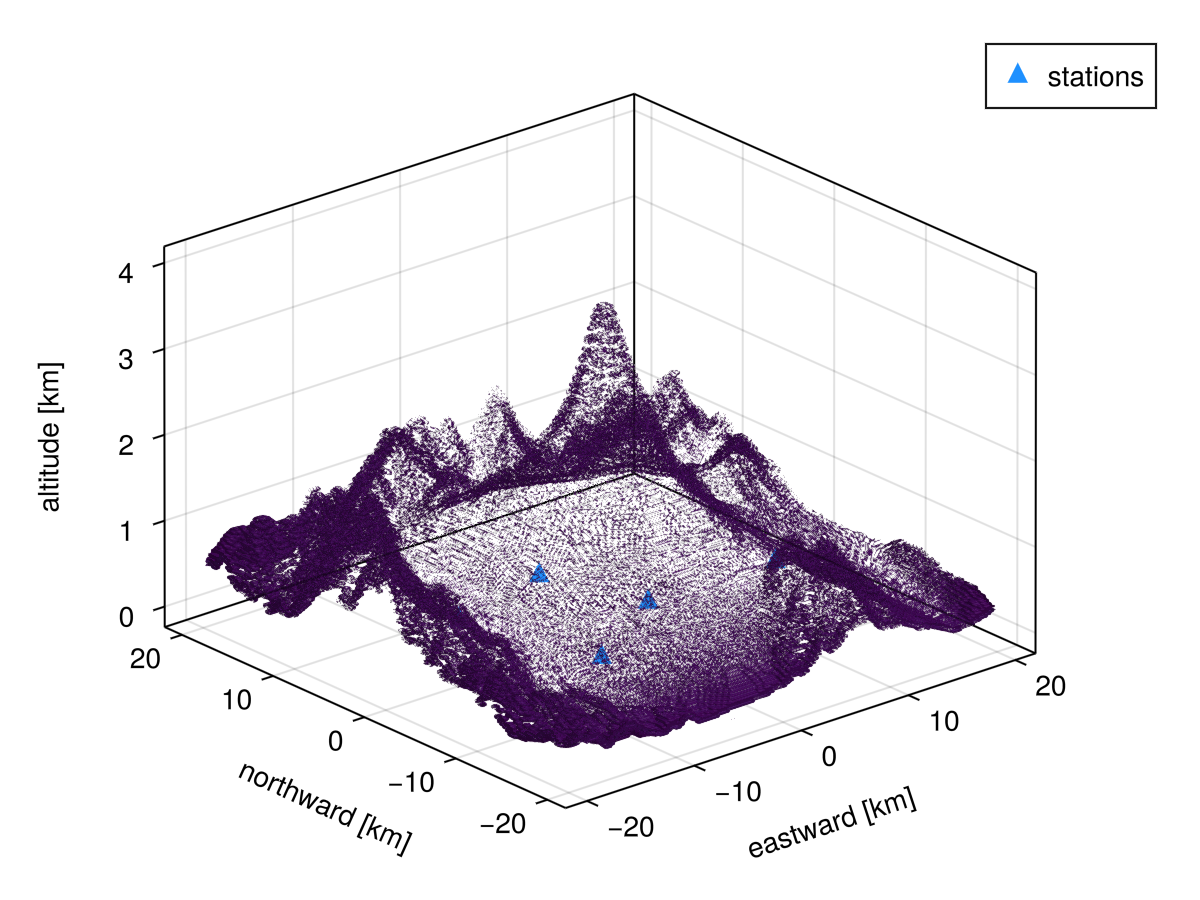

In [115]:
f = Figure()
ax = Axis3(f[1, 1];
    xlabel = "eastward [km]",
    ylabel = "northward [km]",
    zlabel = "altitude [km]",
)

contour!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    abs.(Gg);
    levels = [thr],
    color = (:orange, 0.45),
    transparency = true,
    linewidth = 0,
)


scatter!(
    ax,
    staX, staY, staZ;
    color = :dodgerblue,
    marker = :utriangle,
    markersize = 14,
    label = "stations",
)



axislegend(ax)
#limits!(ax, -200, 200, -200, 200, -400, 5)
f

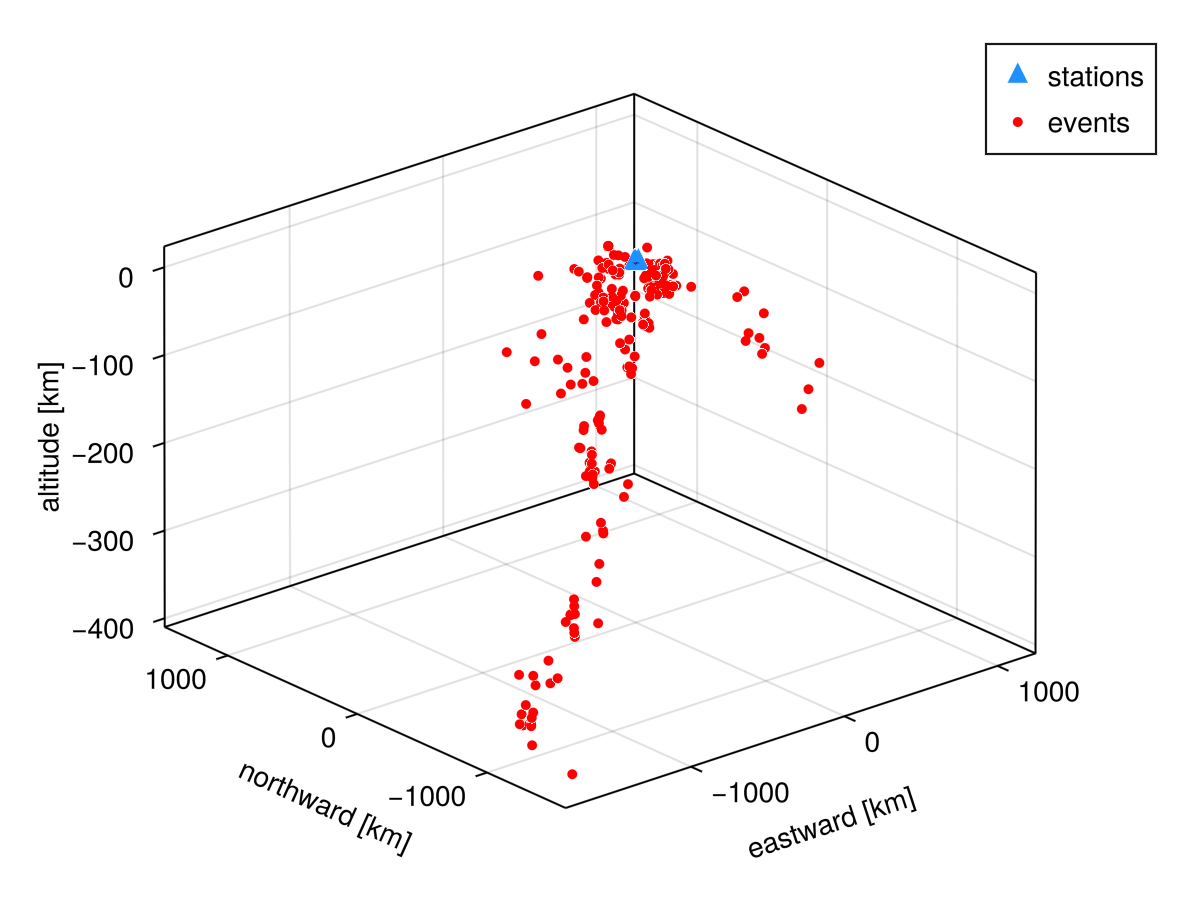

In [118]:
f = Figure()
ax = Axis3(f[1, 1];
    xlabel = "eastward [km]",
    ylabel = "northward [km]",
    zlabel = "altitude [km]",
)

contour!(
    ax,
    xg[1] .. xg[end],
    yg[1] .. yg[end],
    zg[1] .. zg[end],
    abs.(Gg);
    levels = [thr],
    color = (:orange, 0.45),
    transparency = true,
    linewidth = 0,
)


scatter!(
    ax,
    staX, staY, staZ;
    color = :dodgerblue,
    marker = :utriangle,
    markersize = 14,
    label = "stations",
)
scatter!(
    ax,
    eqX, eqY, eqZ;
    color = :red,
    marker = :circle,
    markersize = 7,
    label = "events",
)




axislegend(ax)
#limits!(ax, -200, 200, -200, 200, -400, 5)
f

In [104]:
maximum(eqZ)

-6.85687180402641